In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

import torch
import torch.nn as nn
import torch.optim as optim

from torchviz import make_dot
import numpy as np


7.8 데이터 준비

In [2]:
# 학습용 데이터 준비

# 라이브러리 임포트
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()

# 입력 데이터와 정답 데이터
x_org, y_org = iris.data, iris.target

# 결과 확인
print('원본 데이터', x_org.shape, y_org.shape)

원본 데이터 (150, 4) (150,)


In [3]:
# 입력 데이터에서 1, 3 번째 열 선택(추출)
x_select = x_org[:, [0,2]]
print('선택된 데이터', x_select.shape, y_org.shape)

선택된 데이터 (150, 2) (150,)


In [4]:
# 훈련 데이터와 검증 데이터로 분할(셔플도 동시에 실시함)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_select, y_org, train_size=75, test_size=75, 
    random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(75, 2) (75, 2) (75,) (75,)


산포도 출력

In [5]:
# 데이터를 정답별로 분할

x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]
x_t2 = x_train[y_train == 2]

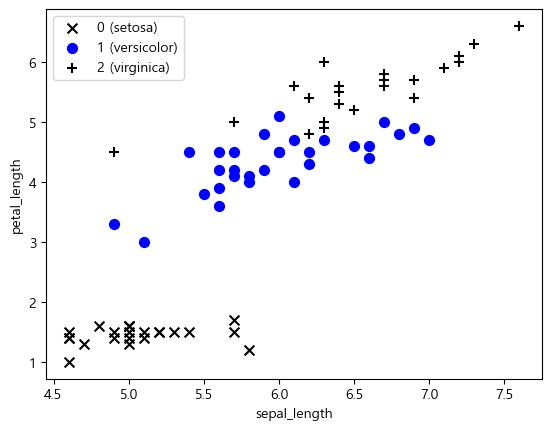

In [6]:
# 산포도 출력

plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='k', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='b', s=50, label='1 (versicolor)')
plt.scatter(x_t2[:,0], x_t2[:,1], marker='+', c='k', s=50, label='2 (virginica)')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

7.9 모델 정의

In [7]:
# 학습용 파라미터 설정

# 입력 차원수
n_input = x_train.shape[1]

# 출력 차원수
# 분류 클래스 수, 여기서는 3
n_output = len(list(set(y_train)))

# 결과 확인
print(f'n_input: {n_input}  n_output: {n_output}')

n_input: 2  n_output: 3


In [8]:
# 모델 정의
# 2입력 3출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)
                
        # 초깃값을 모두 1로 함
        # "딥러닝을 위한 수학"과 조건을 맞추기 위한 목적        
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    def forward(self, x):
        x1 = self.l1(x)
        return x1
    # forward() 메서드에서 활성화 함수를 사용하지 않음

# 인스턴스 생성
net = Net(n_input, n_output)        

모델 확인

In [9]:
# 모델 내부 파라미터 확인
# l1.weight는 행렬, l1.bias는 벡터

for parameter in net.named_parameters():
    print(parameter)

('l1.weight', Parameter containing:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([1., 1., 1.], requires_grad=True))


In [10]:
print(net)

Net(
  (l1): Linear(in_features=2, out_features=3, bias=True)
)


손실 함수와 최적화 함수

In [11]:
# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 학습률
lr = 0.01

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

7.10 경사 하강법

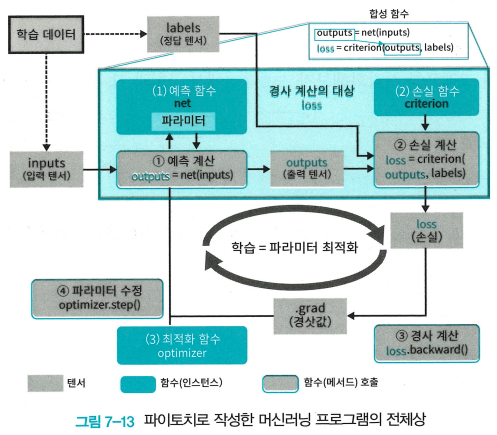

In [12]:
# x_train과 y_train의 텐서 변수화

inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).long()

# 검증 데이터의 텐서 변수화

inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).long()

손실(loss)의 계산 그래프 시각화(옵션)

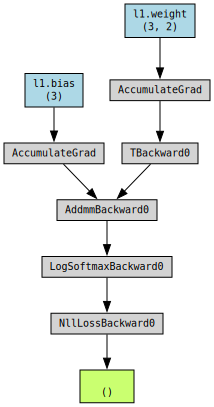

In [13]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels)

# 손실의 계산 그래프 시각화
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

예측 라벨을 얻는 방법

 outputs = net(inputs)에서 나온 출력값(3차원 벡터)로부터 예측 라벨(현재 실습에서는 0, 1, 2 중 하나)을 얻는 방법. outputs는 2차원 데이터.

In [14]:
# torch.max 함수 호출
# 2번째 인수는 축을 의미함. 1이면 '행'별로 집계
print(torch.max(outputs, 1))

torch.return_types.max(
values=tensor([12.0000, 12.7000,  7.6000, 13.0000, 12.3000,  7.6000,  7.3000, 11.1000,
        12.1000, 13.3000,  8.0000,  7.0000, 10.3000,  7.6000, 11.7000, 13.3000,
         7.4000, 13.5000,  8.2000,  8.4000, 12.7000,  6.6000,  7.9000, 12.2000,
        14.6000, 12.0000, 10.2000, 10.5000,  7.1000,  7.3000, 12.6000, 12.7000,
         7.4000,  7.7000, 10.8000, 11.5000, 11.5000, 14.0000, 12.8000, 10.8000,
        10.8000, 15.2000,  7.5000,  7.8000, 11.1000, 13.6000, 12.9000, 14.2000,
        12.7000,  7.6000, 10.9000,  7.0000, 10.9000, 11.2000,  7.4000, 11.7000,
        13.3000, 11.5000, 13.4000, 12.7000,  7.7000, 11.8000,  7.0000, 12.6000,
        11.7000, 10.9000,  9.2000, 12.2000, 10.4000, 12.1000,  7.5000,  9.1000,
        11.1000, 12.0000, 14.3000], grad_fn=<MaxBackward0>),
indices=tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 

In [15]:
# 예측 라벨 리스트를 취득하기 위해, 두번째 indices만을 취하면 된다
torch.max(outputs, 1)[1]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

반복 계산

In [16]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 평가 결과 기록
history = np.zeros((0,5))

In [17]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):

    # 훈련 페이즈
    
    # 경사 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels)

    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()

    # 예측 라벨 산출 * * *
    predicted = torch.max(outputs, 1)[1]

    # 손실과 정확도 계산
    train_loss = loss.item()
    train_acc = (predicted == labels).sum()  / len(labels)

    # 예측 페이즈

    # 예측 계산
    outputs_test = net(inputs_test)

    # 손실 계산
    loss_test = criterion(outputs_test, labels_test)

    # 예측 라벨 산출 * * *
    predicted_test = torch.max(outputs_test, 1)[1]

    # 손실과 정확도 계산
    val_loss =  loss_test.item()
    val_acc =  (predicted_test == labels_test).sum() / len(labels_test)
    
    if ((epoch) % 100 == 0):
        print (f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [0/10000], loss: 1.09861 acc: 0.30667 val_loss: 1.09263, val_acc: 0.26667
Epoch [100/10000], loss: 0.82640 acc: 0.70667 val_loss: 0.83594, val_acc: 0.62667
Epoch [200/10000], loss: 0.70205 acc: 0.82667 val_loss: 0.70067, val_acc: 0.78667
Epoch [300/10000], loss: 0.63000 acc: 0.88000 val_loss: 0.62363, val_acc: 0.82667
Epoch [400/10000], loss: 0.58279 acc: 0.92000 val_loss: 0.57377, val_acc: 0.86667
Epoch [500/10000], loss: 0.54878 acc: 0.90667 val_loss: 0.53819, val_acc: 0.88000
Epoch [600/10000], loss: 0.52256 acc: 0.90667 val_loss: 0.51098, val_acc: 0.88000
Epoch [700/10000], loss: 0.50133 acc: 0.90667 val_loss: 0.48908, val_acc: 0.90667
Epoch [800/10000], loss: 0.48349 acc: 0.89333 val_loss: 0.47079, val_acc: 0.92000
Epoch [900/10000], loss: 0.46811 acc: 0.89333 val_loss: 0.45509, val_acc: 0.92000
Epoch [1000/10000], loss: 0.45458 acc: 0.89333 val_loss: 0.44133, val_acc: 0.92000
Epoch [1100/10000], loss: 0.44247 acc: 0.89333 val_loss: 0.42906, val_acc: 0.92000
Epoch [1200/1000

## 7.11 결과 확인 

## 실습문제 01

In [18]:
# 1. 손실과 정확도 변화 확인

print(f'초기상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기상태 : 손실 : 1.09263  정확도 : 0.26667
최종상태 : 손실 : 0.19854  정확도 : 0.96000


## 실습문제 02

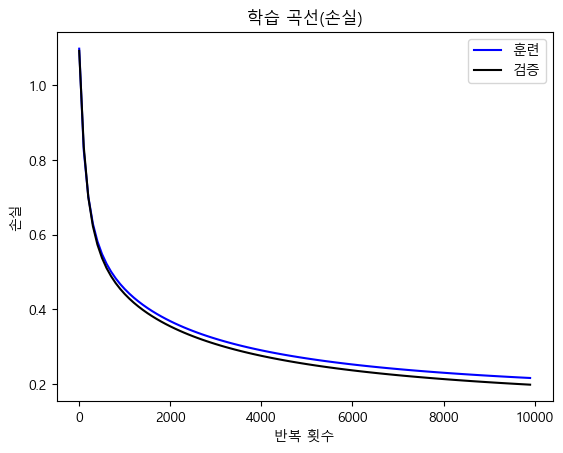

In [19]:
# 2. 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

## 실습문제 03

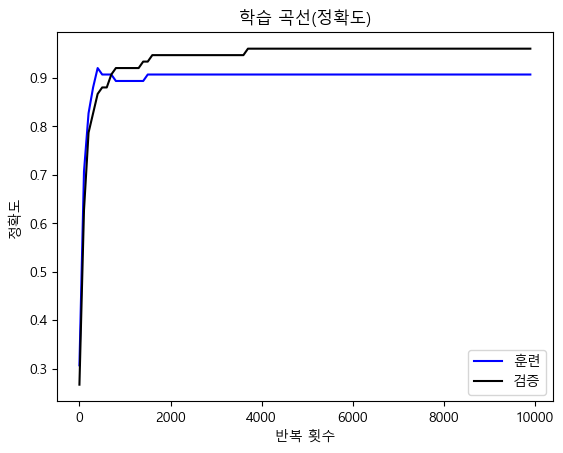

In [20]:
# 3. 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

<small>두 개 모두 괜찮은 모양의 곡선이 그려졌고, 학습이 잘 이뤄졌다는 것을 알 수 있다. 

정확도의 학습 곡선에 관해서는, 훈련 데이터보다 검증 데이터가 더 좋은 정확도를 내고 있다는 점이 약간 이해하기 힘들지만, (검증데이터 손실 값도 더 적다) 데이터를 분할하는 방법에 따라서는 이런 경우도 일어날 수 있다

데이터의 건수가적은 경우, 이상치가 어느 쪽에 포함되는지에 따라 정확도가 크게 변하기도 한다</small>

모델 출력 확인

In [21]:
#모델의 출력이 어떤 수치인지, 그리고 그 수치로부터 확률 값을 얻고 싶을 때는 어떻게 해야 하는지 알아보자

# 0번째, 2번째, 3번째 데이터에 대해 조사하자
# 실제 레이블 추출
print(labels[[0,2,3]])

tensor([1, 0, 2])


In [22]:
# 0번째, 2번째, 3번째 데이터의 입력(특징)값 (x1, x2) 추출

i3 = inputs[[0,2,3],:]
print(i3.data.numpy())

[[6.3 4.7]
 [5.  1.6]
 [6.4 5.6]]


In [23]:
# 출력값에 소프트맥스 함수를 적용한 결과를 취득

softmax = torch.nn.Softmax(dim=1)

o3 = net(i3)
k3 = softmax(o3)

print(o3.data.numpy())
print(k3.data.numpy())

[[ 8.80707    14.19375    12.998569  ]
 [12.826235    9.799994    0.17343739]
 [ 6.79541    15.092805   17.111103  ]]
[[3.5014153e-03 7.6497865e-01 2.3151995e-01]
 [9.5374262e-01 4.6254259e-02 3.0506401e-06]
 [2.9224986e-05 1.1729165e-01 8.8267910e-01]]


In [24]:
print(np.round(k3.data.numpy(), 4))  # 소수점 4자리까지 반올림하여 출력

[[0.0035 0.765  0.2315]
 [0.9537 0.0463 0.    ]
 [0.     0.1173 0.8827]]


가중치 행렬과 바이어스 값

In [25]:
# 가중치 행렬
print(net.l1.weight.data)

# 바이어스
print(net.l1.bias.data)

tensor([[ 3.0452, -2.5735],
        [ 1.3573,  0.8481],
        [-1.4026,  4.7253]])
tensor([ 1.7178,  1.6563, -0.3741])


7.12 입력 변수의 4차원화

In [26]:
# 4차원 데이터 x_org 사용

# 훈련 데이터와 검증 데이터로 분할(셔플도 동시에 실시함)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_org, y_org, train_size=75, test_size=75, 
    random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

# 입력 차원수
n_input = x_train.shape[1]

(75, 4) (75, 4) (75,) (75,)


<small>
위 4차원 특징 벡터를 '선형함수 + 소프트맥스 함수' 다중 분류 모델로 반복 학습 후, 다음을 출력하시오.

1. 손실과 정확도 변화 확인
2. 학습 곡선 출력(손실)
3. 학습 곡선 출력(정확도)
4. 2차원 특징 벡터를 사용했을 때와 비교할 때 어떤 결과가 달라졌는지 간단히 서술하시오.
</small>

In [ ]:
# 4차원 입력으로 모델 재정의 및 학습

# 출력 차원수
n_output = len(list(set(y_train)))

# 학습률
lr = 0.01

# 초기화 (4입력 3출력)
net = Net(n_input, n_output)

# 손실 함수: 교차 엔트로피
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 텐서 변환
inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).long()
inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).long()

# 반복 횟수
num_epochs = 10000

# 평가 결과 기록
history = np.zeros((0, 5))

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # 훈련 페이즈
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    predicted = torch.max(outputs, 1)[1]
    train_loss = loss.item()
    train_acc = (predicted == labels).sum() / len(labels)

    # 검증 페이즈
    outputs_test = net(inputs_test)
    loss_test = criterion(outputs_test, labels_test)
    predicted_test = torch.max(outputs_test, 1)[1]
    val_loss = loss_test.item()
    val_acc = (predicted_test == labels_test).sum() / len(labels_test)

    if epoch % 100 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))